# 1.1

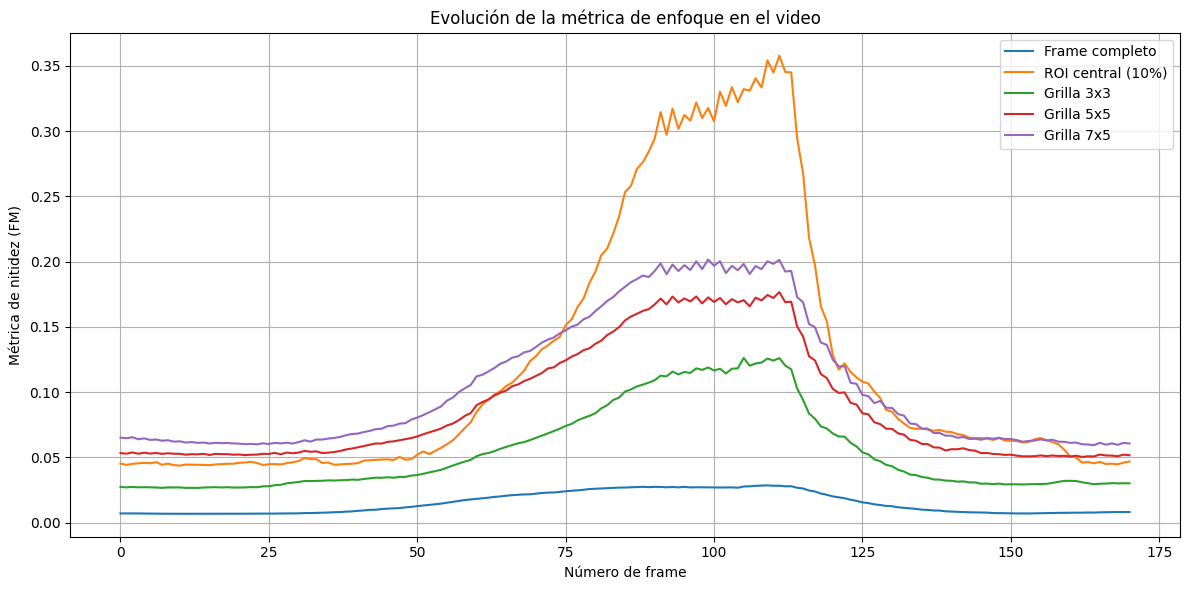

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Se define la métrica propuesta en el paper
def sharpness_frequency_metric(image_gray):
    # FFT centrada
    F = np.fft.fft2(image_gray)
    Fc = np.fft.fftshift(F)
    AF = np.abs(Fc)
    
    # Umbral como M/1000
    M = np.max(AF)
    threshold = M / 1000
    
    # Cantidad de pixeles con valor mayor al umbral
    TH = np.sum(AF > threshold)
    
    # FM: fracción de pixeles sobre el umbral
    FM = TH / AF.size
    return FM

# Métrica sobre bloques NxM
def sharpness_grid_metric(gray_image, N, M):
    h, w = gray_image.shape
    block_h, block_w = h // N, w // M
    metrics_matrix = np.zeros((N, M))
    
    for i in range(N):
        for j in range(M):
            y1 = i * block_h
            x1 = j * block_w
            block = gray_image[y1:y1 + block_h, x1:x1 + block_w]
            metrics_matrix[i, j] = sharpness_frequency_metric(block)
            
    return metrics_matrix

# ruta del video
video_path = "vision_computadora_I/Material_TPs/TP2/focus_video.mov"
cap = cv2.VideoCapture(video_path)

frame_metrics = []
roi_metrics = []
frame_ids = []

# Se procesan 3 configuraciones de grillas: 3x3, 5x5, 7x5 sobre todos los frames
grid_configs = [(3, 3), (5, 5), (7, 5)]
grid_results = {f"{n}x{m}": [] for n, m in grid_configs}

frame_index = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frame_ids.append(frame_index)

    # Métrica en todo el frame
    frame_metrics.append(sharpness_frequency_metric(gray))

    # Métrica en ROI central del 10%
    h, w = gray.shape
    roi_h, roi_w = int(h * 0.316), int(w * 0.316) # 10% del área: 0.316^2 ≈ 10%
    y1, x1 = (h - roi_h) // 2, (w - roi_w) // 2
    roi = gray[y1:y1+roi_h, x1:x1+roi_w]
    roi_metrics.append(sharpness_frequency_metric(roi))
    
    # Métricas sobre grillas
    for (n, m) in grid_configs:
        matrix = sharpness_grid_metric(gray, n, m)
        avg_metric = matrix.mean()
        grid_results[f"{n}x{m}"].append(avg_metric)

    frame_index += 1

cap.release()

# Graficamos
plt.figure(figsize=(12, 6))

# Gráficos de las métricas "frame completo" y "ROI central"
plt.plot(frame_ids, frame_metrics, label="Frame completo")
plt.plot(frame_ids, roi_metrics, label="ROI central (10%)")

# Curvas de grillas
plt.plot(frame_ids, grid_results["3x3"], label="Grilla 3x3")
plt.plot(frame_ids, grid_results["5x5"], label="Grilla 5x5")
plt.plot(frame_ids, grid_results["7x5"], label="Grilla 7x5")

plt.xlabel("Número de frame")
plt.ylabel("Métrica de nitidez (FM)")
plt.title("Evolución de la métrica de enfoque en el video")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 1.2

In [21]:
def sharpness_tenengrad_metric(image_gray):
    # Gradiente Sobel en X y en Y
    gx = cv2.Sobel(image_gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image_gray, cv2.CV_64F, 0, 1, ksize=3)

    # Magnitud del gradiente
    magnitude = np.sqrt(gx**2 + gy**2)

    # Retorna la energía del gradiente (media cuadrática)
    return np.mean(magnitude**2)


# Métrica sobre bloques NxM
def sharpness_grid_metric(gray_image, N, M):
    h, w = gray_image.shape
    block_h, block_w = h // N, w // M
    metrics_matrix = np.zeros((N, M))
    
    for i in range(N):
        for j in range(M):
            y1 = i * block_h
            x1 = j * block_w
            block = gray_image[y1:y1 + block_h, x1:x1 + block_w]
            metrics_matrix[i, j] = sharpness_tenengrad_metric(block)
            
    return metrics_matrix

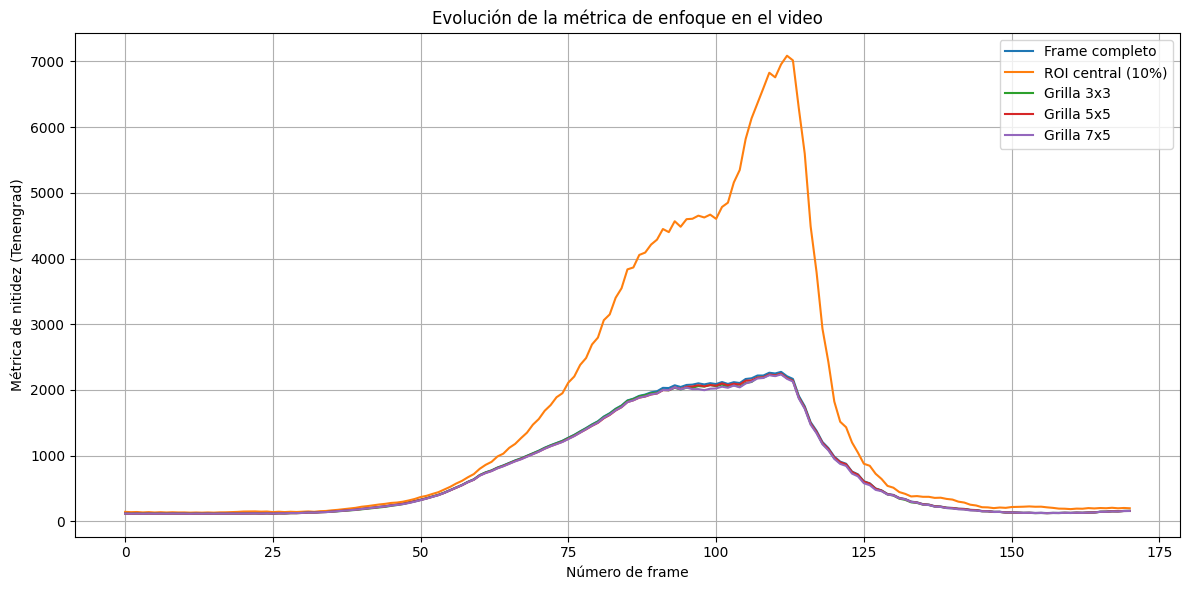

In [22]:
# ruta del video
video_path = "vision_computadora_I/Material_TPs/TP2/focus_video.mov"
cap = cv2.VideoCapture(video_path)

# Se procesan 3 configuraciones de grillas: 3x3, 5x5, 7x5 sobre todos los frames
grid_configs = [(3, 3), (5, 5), (7, 5)]
grid_results = {f"{n}x{m}": [] for n, m in grid_configs}

frame_metrics = []
roi_metrics = []
frame_ids = []

frame_index = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frame_ids.append(frame_index)

    # Métrica en todo el frame
    frame_metrics.append(sharpness_tenengrad_metric(gray))

    # Métrica en ROI central del 10%
    h, w = gray.shape
    roi_h, roi_w = int(h * 0.316), int(w * 0.316) # 10% del área: 0.316^2 ≈ 10%
    y1, x1 = (h - roi_h) // 2, (w - roi_w) // 2
    roi = gray[y1:y1+roi_h, x1:x1+roi_w]
    roi_metrics.append(sharpness_tenengrad_metric(roi))
    
    # Métricas sobre grillas
    for (n, m) in grid_configs:
        matrix = sharpness_grid_metric(gray, n, m)
        avg_metric = matrix.mean()
        grid_results[f"{n}x{m}"].append(avg_metric)

    frame_index += 1

cap.release()

# Graficamos
plt.figure(figsize=(12, 6))

# Gráficos de las métricas "frame completo" y "ROI central"
plt.plot(frame_ids, frame_metrics, label="Frame completo")
plt.plot(frame_ids, roi_metrics, label="ROI central (10%)")

# Curvas de grillas
plt.plot(frame_ids, grid_results["3x3"], label="Grilla 3x3")
plt.plot(frame_ids, grid_results["5x5"], label="Grilla 5x5")
plt.plot(frame_ids, grid_results["7x5"], label="Grilla 7x5")

plt.xlabel("Número de frame")
plt.ylabel("Métrica de nitidez (Tenengrad)")
plt.title("Evolución de la métrica de enfoque en el video")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


> Chequear

---

¿Por qué la ROI central se comporta distinto, pero las grillas y el frame completo son tan parecidos?
1. La ROI está muy localizada
Es un 10% del área, centrada, y suele estar justo donde el objeto principal aparece o desaparece del foco.

Por eso, tiene un pico abrupto y aislado, detectando el foco más preciso.

2. El frame completo y las grillas promedian todo el contenido
El frame completo calcula la métrica sobre todo, incluyendo bordes, fondo, zonas con poco detalle.

Las grillas NxM dividen el frame y luego se promedia la métrica de todos los bloques.

Como resultado, ambos se comportan de forma promediada y suavizada, con curvas similares en forma y escala.

3. Si el foco afecta a todo el campo por igual, entonces no hay tanta diferencia entre zonas
En este video en particular, parece que el desenfoque no es muy localizado (como en microscopía), sino más uniforme.

In [25]:
import cv2
import numpy as np

# Reabrimos el video para aplicar unsharp masking y recalcular la métrica en el frame de mayor nitidez (ROI central)
video_path = "vision_computadora_I/Material_TPs/TP2/focus_video.mov"
cap = cv2.VideoCapture(video_path)

# Calculamos de nuevo los valores de nitidez en ROI central (Tenengrad) para detectar el frame de máximo enfoque
def sharpness_tenengrad_metric(image_gray):
    gx = cv2.Sobel(image_gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image_gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx**2 + gy**2)
    return np.mean(magnitude**2)

roi_metrics = []
roi_frames = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    roi_h, roi_w = int(h * 0.316), int(w * 0.316)
    y1, x1 = (h - roi_h) // 2, (w - roi_w) // 2
    roi = gray[y1:y1+roi_h, x1:x1+roi_w]
    roi_metrics.append(sharpness_tenengrad_metric(roi))
    roi_frames.append(frame)

cap.release()

# Encontramos el frame de máximo enfoque (ROI)
best_idx = int(np.argmax(roi_metrics))
frame_max_focus = roi_frames[best_idx]

# Aplicamos Unsharp Masking
def unsharp_mask(image, sigma=1.0, strength=1.5):
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)
    sharpened = cv2.addWeighted(image, 1 + strength, blurred, -strength, 0)
    return sharpened

gray_orig = cv2.cvtColor(frame_max_focus, cv2.COLOR_BGR2GRAY)
gray_sharp = unsharp_mask(gray_orig, sigma=1.0, strength=1.5)

# Recalculamos la métrica Tenengrad sobre la imagen mejorada
sharpness_before = sharpness_tenengrad_metric(gray_orig)
sharpness_after = sharpness_tenengrad_metric(gray_sharp)

# Mostramos ambas imágenes
comparison = cv2.hconcat([
    cv2.cvtColor(gray_orig, cv2.COLOR_GRAY2BGR),
    cv2.cvtColor(gray_sharp, cv2.COLOR_GRAY2BGR)
])

import PIL.Image
PIL.Image.fromarray(comparison), sharpness_before, sharpness_after


(<PIL.Image.Image image mode=RGB size=1280x360>,
 np.float64(2207.5707291666668),
 np.float64(5104.423342013889))

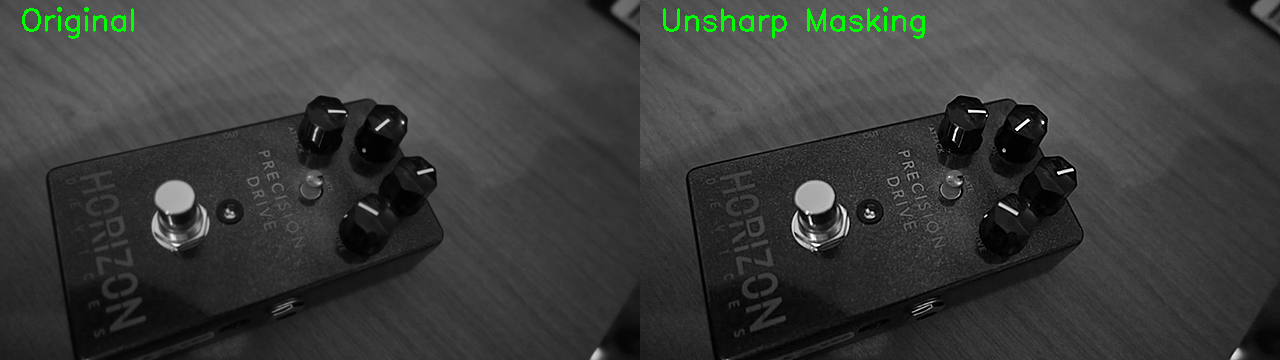

In [26]:
# Mostramos ambas imágenes (original y con unsharp masking) con etiquetas superpuestas
comparison_annotated = comparison.copy()
cv2.putText(comparison_annotated, "Original", (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
cv2.putText(comparison_annotated, "Unsharp Masking", (comparison.shape[1]//2 + 20, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

# Convertimos para visualización
from PIL import Image
Image.fromarray(comparison_annotated)


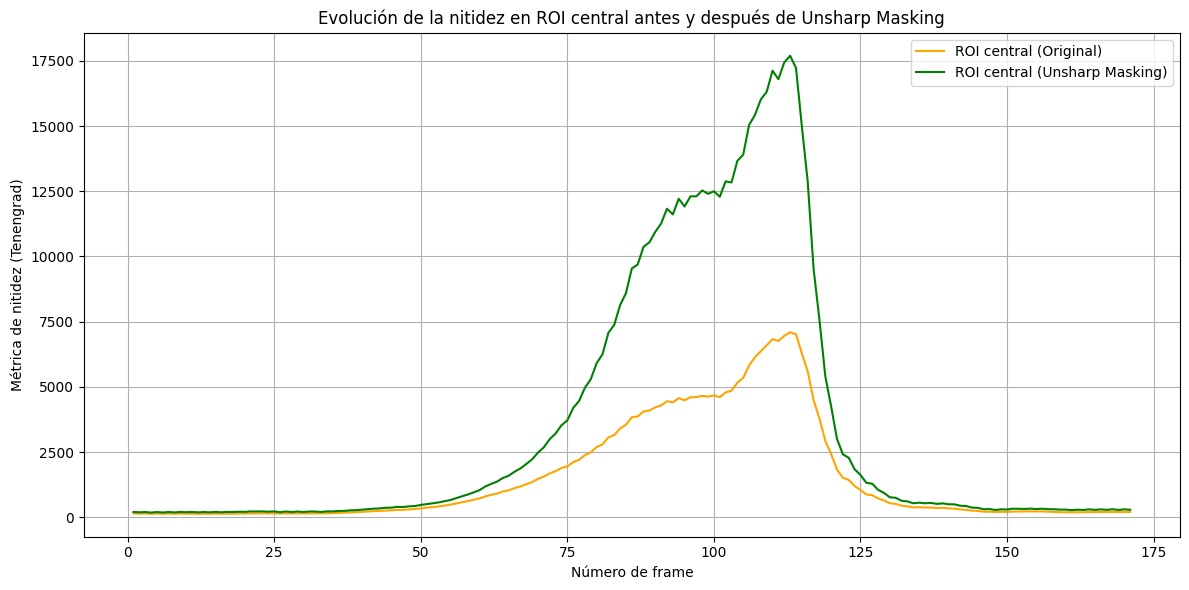

In [28]:
# Reabrimos el video y calculamos la métrica Tenengrad sobre la ROI central, con y sin unsharp masking
cap = cv2.VideoCapture(video_path)

roi_sharpness_orig = []
roi_sharpness_unsharp = []
frame_ids = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    roi_h, roi_w = int(h * 0.316), int(w * 0.316)
    y1, x1 = (h - roi_h) // 2, (w - roi_w) // 2
    roi = gray[y1:y1+roi_h, x1:x1+roi_w]
    roi_sharpness_orig.append(sharpness_tenengrad_metric(roi))

    roi_unsharp = unsharp_mask(roi, sigma=1.0, strength=1.5)
    roi_sharpness_unsharp.append(sharpness_tenengrad_metric(roi_unsharp))

    frame_ids.append(int(cap.get(cv2.CAP_PROP_POS_FRAMES)))

cap.release()

# Graficamos la evolución de la nitidez en la ROI
plt.figure(figsize=(12, 6))
plt.plot(frame_ids, roi_sharpness_orig, label="ROI central (Original)", color='orange')
plt.plot(frame_ids, roi_sharpness_unsharp, label="ROI central (Unsharp Masking)", color='green')
plt.xlabel("Número de frame")
plt.ylabel("Métrica de nitidez (Tenengrad)")
plt.title("Evolución de la nitidez en ROI central antes y después de Unsharp Masking")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

